•	Source of dataset

•	Description of features and target
variable


•	EDA

•	Handling missing values

•	Feature scaling and normalization

•	Train–test split

•	Training model used-
	SVM

•	Model assumptions

•	Evaluation metrics--

o	Accuracy, Precision, Recall, F1-score

•	Predictive System for test data

•	Confusion matrix

•	Graphical analysis

•	Model comparison


In [2]:
import numpy as np
%matplotlib inline
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from numpy import corrcoef,array
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.svm import SVC
#from google.colab import drive
#drive.mount('/content/drive')

ModuleNotFoundError: No module named 'numpy'

In [6]:
#source of dataset
data=pd.read_csv("HARSmartPhone/train.csv")
data


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347,0.299665,-0.057193,-0.181233,-0.195387,0.039905,0.077078,-0.282301,0.043616,0.060410,0.210795,...,-0.880324,-0.190437,0.829718,0.206972,-0.425619,-0.791883,0.238604,0.049819,30,WALKING_UPSTAIRS
7348,0.273853,-0.007749,-0.147468,-0.235309,0.004816,0.059280,-0.322552,-0.029456,0.080585,0.117440,...,-0.680744,0.064907,0.875679,-0.879033,0.400219,-0.771840,0.252676,0.050053,30,WALKING_UPSTAIRS
7349,0.273387,-0.017011,-0.045022,-0.218218,-0.103822,0.274533,-0.304515,-0.098913,0.332584,0.043999,...,-0.304029,0.052806,-0.266724,0.864404,0.701169,-0.779133,0.249145,0.040811,30,WALKING_UPSTAIRS
7350,0.289654,-0.018843,-0.158281,-0.219139,-0.111412,0.268893,-0.310487,-0.068200,0.319473,0.101702,...,-0.344314,-0.101360,0.700740,0.936674,-0.589479,-0.785181,0.246432,0.025339,30,WALKING_UPSTAIRS


In [7]:
data2=pd.read_csv("HARSmartPhone/test.csv")
data2

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,STANDING
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2942,0.310155,-0.053391,-0.099109,-0.287866,-0.140589,-0.215088,-0.356083,-0.148775,-0.232057,0.185361,...,-0.750809,-0.337422,0.346295,0.884904,-0.698885,-0.651732,0.274627,0.184784,24,WALKING_UPSTAIRS
2943,0.363385,-0.039214,-0.105915,-0.305388,0.028148,-0.196373,-0.373540,-0.030036,-0.270237,0.185361,...,-0.700274,-0.736701,-0.372889,-0.657421,0.322549,-0.655181,0.273578,0.182412,24,WALKING_UPSTAIRS
2944,0.349966,0.030077,-0.115788,-0.329638,-0.042143,-0.250181,-0.388017,-0.133257,-0.347029,0.007471,...,-0.467179,-0.181560,0.088574,0.696663,0.363139,-0.655357,0.274479,0.181184,24,WALKING_UPSTAIRS
2945,0.237594,0.018467,-0.096499,-0.323114,-0.229775,-0.207574,-0.392380,-0.279610,-0.289477,0.007471,...,-0.617737,0.444558,-0.819188,0.929294,-0.008398,-0.659719,0.264782,0.187563,24,WALKING_UPSTAIRS


EDA

Exploratory Data Analysis was performed to understand the structure and distribution of the dataset. The dataset contains sensor-based numerical features with no missing values. Activity-wise analysis shows distinct patterns between static and dynamic activities. Statistical summaries indicated varying feature ranges, justifying the need for standardization before applying SVM.

Static activities show lower energy and variance, while dynamic activities show higher values.

In [8]:
#unique activities
df=pd.DataFrame(data)
print(df.isnull().values.any())
print(df["Activity"].unique())

False
['STANDING' 'SITTING' 'LAYING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


In [9]:
#data types
df.dtypes

tBodyAcc-mean()-X       float64
tBodyAcc-mean()-Y       float64
tBodyAcc-mean()-Z       float64
tBodyAcc-std()-X        float64
tBodyAcc-std()-Y        float64
                         ...   
angle(X,gravityMean)    float64
angle(Y,gravityMean)    float64
angle(Z,gravityMean)    float64
subject                   int64
Activity                 object
Length: 563, dtype: object

In [10]:
df['Activity'].value_counts()

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

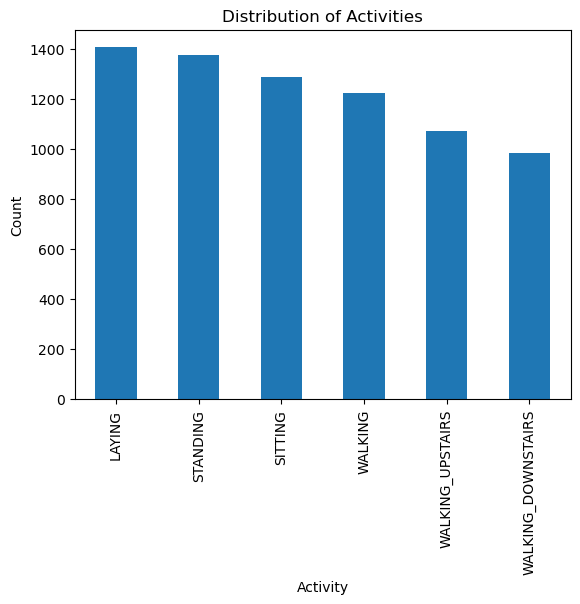

In [11]:
df['Activity'].value_counts().plot(kind='bar')
plt.title("Distribution of Activities")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.show()

Time-Domain Body Acceleration (tBodyAcc)
What it represents: Linear acceleration of the body (gravity removed).

Axial Features (X, Y, Z)

Mean, Std, MAD, Max, Min

SMA, Energy, IQR, Entropy

AR coefficients (1–4)

Axis correlations

📌 Used for: distinguishing static vs dynamic activities.

Time-Domain Gravity Acceleration (tGravityAcc)
What it represents: Gravity component extracted using low-pass filtering.

📌 Used for: posture recognition (sitting, standing, laying).

Time-Domain Body Acceleration Jerk (tBodyAccJerk)
What it represents: Rate of change of acceleration → sudden movements.

📌 Used for: transitions, walking upstairs/downstairs.

Time-Domain Body Gyroscope (tBodyGyro)
What it represents: Angular velocity of the body.

📌 Used for: rotational motion and orientation changes.

Time-Domain Body Gyro Jerk (tBodyGyroJerk)
What it represents: Angular acceleration.

Same structure as tBodyAccJerk, but rotational.

📌 Used for: abrupt turns, quick rotations.

Magnitude-Based Time Features (*Mag)
These collapse X, Y, Z into a single magnitude signal.

Statistics mean, std, mad, max, min, sma, energy, iqr, entropy, arCoeff(1–4)

📌 Used for: orientation-independent movement intensity.

Frequency-Domain Body Acceleration (fBodyAcc)
FFT applied to time signals.

Features include:

Mean, Std, MAD, Max, Min

SMA, Energy, IQR, Entropy

Max frequency index

Mean frequency

Skewness, Kurtosis

Band energy (multiple frequency bands)

📌 Used for: periodicity detection (walking rhythms).

Frequency-Domain Jerk & Gyroscope
📌 Used for: frequency patterns of motion & rotation.

Angle-Based Features
Orientation between body signals and gravity.

📌 Used for: posture & device orientation.

Subject Identifier subject
📌 Used only for cross-subject validation, not training features.

In [12]:
print("Information about data\n")
df.info()
print("\n")
print("Shape of data")
df.shape

Information about data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB


Shape of data


(7352, 563)

In [13]:
columns=df.columns
print(*columns)

tBodyAcc-mean()-X tBodyAcc-mean()-Y tBodyAcc-mean()-Z tBodyAcc-std()-X tBodyAcc-std()-Y tBodyAcc-std()-Z tBodyAcc-mad()-X tBodyAcc-mad()-Y tBodyAcc-mad()-Z tBodyAcc-max()-X tBodyAcc-max()-Y tBodyAcc-max()-Z tBodyAcc-min()-X tBodyAcc-min()-Y tBodyAcc-min()-Z tBodyAcc-sma() tBodyAcc-energy()-X tBodyAcc-energy()-Y tBodyAcc-energy()-Z tBodyAcc-iqr()-X tBodyAcc-iqr()-Y tBodyAcc-iqr()-Z tBodyAcc-entropy()-X tBodyAcc-entropy()-Y tBodyAcc-entropy()-Z tBodyAcc-arCoeff()-X,1 tBodyAcc-arCoeff()-X,2 tBodyAcc-arCoeff()-X,3 tBodyAcc-arCoeff()-X,4 tBodyAcc-arCoeff()-Y,1 tBodyAcc-arCoeff()-Y,2 tBodyAcc-arCoeff()-Y,3 tBodyAcc-arCoeff()-Y,4 tBodyAcc-arCoeff()-Z,1 tBodyAcc-arCoeff()-Z,2 tBodyAcc-arCoeff()-Z,3 tBodyAcc-arCoeff()-Z,4 tBodyAcc-correlation()-X,Y tBodyAcc-correlation()-X,Z tBodyAcc-correlation()-Y,Z tGravityAcc-mean()-X tGravityAcc-mean()-Y tGravityAcc-mean()-Z tGravityAcc-std()-X tGravityAcc-std()-Y tGravityAcc-std()-Z tGravityAcc-mad()-X tGravityAcc-mad()-Y tGravityAcc-mad()-Z tGravityAcc-m

In [14]:
#statistical summary
df.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515,17.413085
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122,8.975143
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414,8.000000
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181,19.000000
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659,26.000000
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000,30.000000


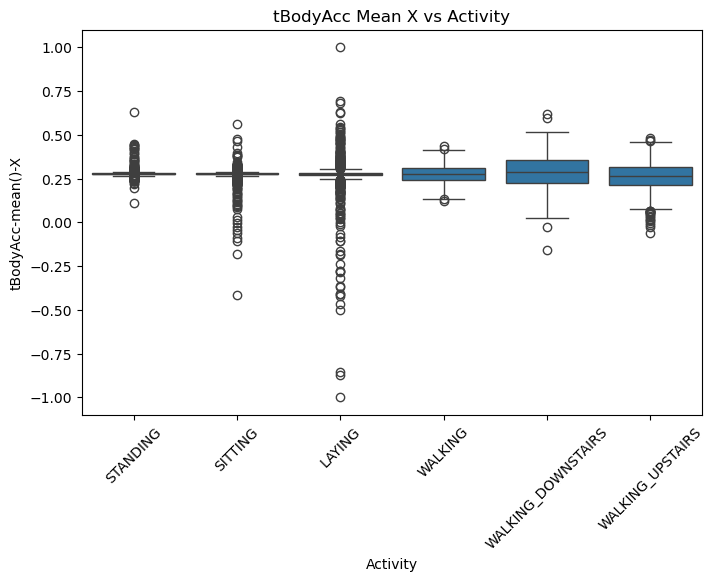

In [15]:
#Accelerometer Mean vs Activity
plt.figure(figsize=(8,5))
sns.boxplot(x='Activity', y='tBodyAcc-mean()-X', data=df)
plt.xticks(rotation=45)
plt.title("tBodyAcc Mean X vs Activity")
plt.show()

In [16]:
df.groupby('Activity')[[
    'tBodyAccMag-mean()',
    'tBodyGyroMag-std()'
]].mean()

,tBodyAccMag-mean(),tBodyGyroMag-std()
Activity,,
LAYING,-0.933299,-0.937940
SITTING,-0.955068,-0.950858
STANDING,-0.956789,-0.935924
WALKING,-0.160787,-0.360968
WALKING_DOWNSTAIRS,0.137366,-0.227265
WALKING_UPSTAIRS,-0.075450,-0.303978


In [17]:
static_acts = ['LAYING', 'SITTING', 'STANDING']
df['ActivityType'] = df['Activity'].apply(
    lambda x: 'Static' if x in static_acts else 'Dynamic'
)
df['ActivityType'].value_counts()

ActivityType
Static     4067
Dynamic    3285
Name: count, dtype: int64

This shows how different activities move differently when we look at their movement numbers. Mean → average value Standard deviation → spread around the average Observation (math-based) −0.957≈−0.955≈−0.933

✔ All are very close ✔ All are strongly negative

📌 Interpretation Static activities cluster near −1, while dynamic activities move toward 0, making these features highly discriminative.

LAYING Lowest movement and rotation → most stable posture

SITTING & STANDING Almost identical → hard to separate using only these two features

WALKING_DOWNSTAIRS Highest acceleration & rotation → impact + gravity effect

WALKING_UPSTAIRS Slightly less movement than downstairs → controlled motion

In [18]:
var_features = df.filter(
    regex='(std\\(\\)|mad\\(\\)|iqr\\(\\))'
).columns
df.groupby('ActivityType')[var_features].mean()

,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-iqr()-X,tBodyAcc-iqr()-Y,tBodyAcc-iqr()-Z,tGravityAcc-std()-X,...,fBodyAccMag-iqr(),fBodyBodyAccJerkMag-std(),fBodyBodyAccJerkMag-mad(),fBodyBodyAccJerkMag-iqr(),fBodyBodyGyroMag-std(),fBodyBodyGyroMag-mad(),fBodyBodyGyroMag-iqr(),fBodyBodyGyroJerkMag-std(),fBodyBodyGyroJerkMag-mad(),fBodyBodyGyroJerkMag-iqr()
ActivityType,,,,,,,,,,,,,,,,,,,,,
Dynamic,-0.146916,0.016088,-0.188298,-0.200216,-0.018922,-0.193787,-0.316752,-0.264969,-0.2507,-0.958715,...,-0.351163,-0.241059,-0.180805,-0.308243,-0.384256,-0.338691,-0.413602,-0.561270,-0.518792,-0.514163
Static,-0.975796,-0.936627,-0.941133,-0.978071,-0.937218,-0.939225,-0.981258,-0.949735,-0.9383,-0.969213,...,-0.972693,-0.974756,-0.972487,-0.977778,-0.942154,-0.946336,-0.967114,-0.979073,-0.978032,-0.979351


In [19]:
energy_features = df.filter(regex='energy').columns
df.groupby('ActivityType')[energy_features].mean()


,tBodyAcc-energy()-X,tBodyAcc-energy()-Y,tBodyAcc-energy()-Z,tGravityAcc-energy()-X,tGravityAcc-energy()-Y,tGravityAcc-energy()-Z,tBodyAccJerk-energy()-X,tBodyAccJerk-energy()-Y,tBodyAccJerk-energy()-Z,tBodyGyro-energy()-X,...,fBodyAccJerk-energy()-X,fBodyAccJerk-energy()-Y,fBodyAccJerk-energy()-Z,fBodyGyro-energy()-X,fBodyGyro-energy()-Y,fBodyGyro-energy()-Z,fBodyAccMag-energy(),fBodyBodyAccJerkMag-energy(),fBodyBodyGyroMag-energy(),fBodyBodyGyroJerkMag-energy()
ActivityType,,,,,,,,,,,,,,,,,,,,,
Dynamic,-0.600515,-0.790338,-0.671937,0.766033,-0.901809,-0.917290,-0.665975,-0.616890,-0.838674,-0.781260,...,-0.665574,-0.617065,-0.838733,-0.809787,-0.729280,-0.708438,-0.606533,-0.648529,-0.726011,-0.857455
Static,-0.997357,-0.991963,-0.986204,0.170710,-0.591912,-0.605304,-0.999408,-0.998497,-0.999218,-0.996342,...,-0.999410,-0.998506,-0.999223,-0.997516,-0.998131,-0.997222,-0.987808,-0.998610,-0.994062,-0.999053


   fBodyAcc-sma()  fBodyAccJerk-sma()  angle(X,gravityMean)  tBodyAcc-std()-X  \
0       -0.974733           -0.990515             -0.841247         -0.995279   
1       -0.985812           -0.989851             -0.844788         -0.998245   
2       -0.985821           -0.987237             -0.848933         -0.995380   
3       -0.992812           -0.992657             -0.848649         -0.996091   
4       -0.992423           -0.993259             -0.847865         -0.998139   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  
0         -0.983111         -0.913526  
1         -0.975300         -0.960322  
2         -0.967187         -0.978944  
3         -0.983403         -0.990675  
4         -0.980817         -0.990482  
                      fBodyAcc-sma()  fBodyAccJerk-sma()  \
fBodyAcc-sma()              1.000000            0.988217   
fBodyAccJerk-sma()          0.988217            1.000000   
angle(X,gravityMean)       -0.384760           -0.384979   
tBodyAcc-std()-X            0.970

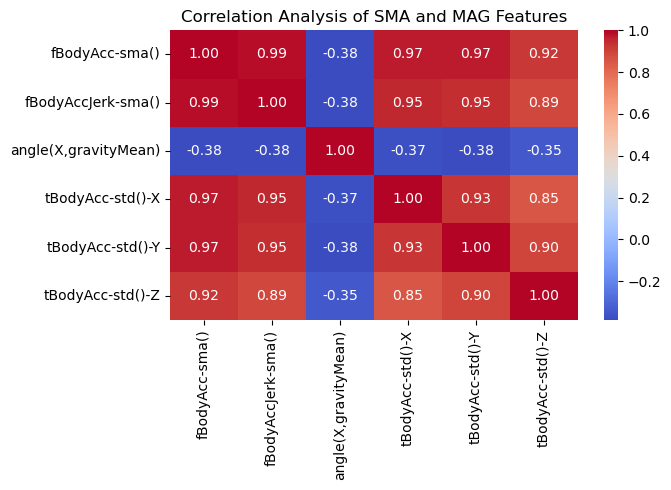

In [20]:
#Correlation Analysis
df_feat = df.drop(columns=['activity', 'subject'], errors='ignore')
selected_features = [
    'fBodyAcc-sma()',
    'fBodyAccJerk-sma()'
    ,'angle(X,gravityMean)',
 'tBodyAcc-std()-X','tBodyAcc-std()-Y','tBodyAcc-std()-Z'


]

df_selected = df_feat[selected_features]
print(df_selected.head())
corr_matrix = df_selected.corr()
print(corr_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Analysis of SMA and MAG Features")
plt.tight_layout()
plt.show()



In [21]:
#Mean of activity subjectwise
full_df = pd.concat([data, data2], axis=0, ignore_index=True)
full_df_no_activity = full_df.drop(columns=['Activity'])
subject_mean_df = full_df_no_activity.groupby('subject').mean()

print(subject_mean_df)
print(subject_mean_df.shape)


         tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  \
subject                                                            
1                 0.265697          -0.018298          -0.107846   
2                 0.273113          -0.019132          -0.115650   
3                 0.273429          -0.017856          -0.106493   
4                 0.274183          -0.014808          -0.107521   
5                 0.279178          -0.015483          -0.105662   
6                 0.272377          -0.017570          -0.115995   
7                 0.270212          -0.018790          -0.112492   
8                 0.270759          -0.018189          -0.106810   
9                 0.270314          -0.020947          -0.101234   
10                0.276848          -0.017836          -0.111302   
11                0.276585          -0.019127          -0.108942   
12                0.273609          -0.018337          -0.106649   
13                0.275896          -0.017650   

Data Standardization

Train-test split

In [22]:
#separating data and labels
X_train = data.drop(columns=['Activity', 'subject'], errors='ignore')
y_train = data['Activity']

X_test = data2.drop(columns=['Activity', 'subject'], errors='ignore')
y_test = data2['Activity']

In [23]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training model

In [25]:
svm_model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)
svm_model.fit(X_train_scaled, y_train_enc)

SVC(C=1)

Model Evaluation

o Accuracy, Precision, Recall, F1-score

• Confusion matrix and graph

In [26]:
y_pred = svm_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test_enc, y_pred))
print("\nClassification Report:\n",
      classification_report(y_test_enc, y_pred,
      target_names=label_encoder.classes_))

print("\nConfusion Matrix:\n", confusion_matrix(y_test_enc, y_pred))


Accuracy: 0.9518154054971157

Classification Report:
                     precision    recall  f1-score   support

            LAYING       0.99      1.00      1.00       537
           SITTING       0.94      0.90      0.92       491
          STANDING       0.92      0.95      0.93       532
           WALKING       0.96      0.97      0.97       496
WALKING_DOWNSTAIRS       0.98      0.92      0.95       420
  WALKING_UPSTAIRS       0.93      0.97      0.95       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947


Confusion Matrix:
 [[537   0   0   0   0   0]
 [  3 441  46   0   0   1]
 [  0  29 503   0   0   0]
 [  0   0   0 482   8   6]
 [  0   0   0   6 386  28]
 [  0   0   0  14   1 456]]


['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


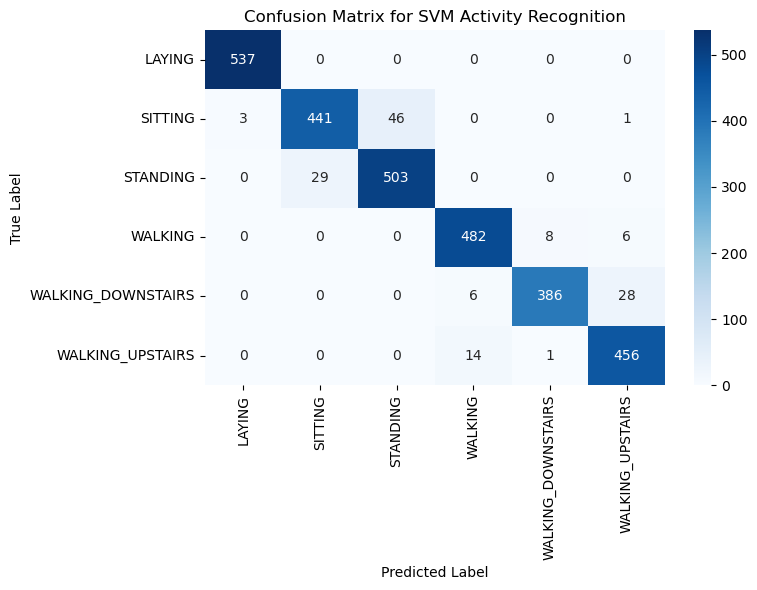

In [27]:
#confusion matrix graph
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
print(le.classes_)

cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for SVM Activity Recognition")
plt.tight_layout()
plt.show()


PREDICTIVE SYSTEM

why use reshape(1,-1) Machine learning models in scikit-learn require a 2-D input. The reshape(1, -1) method converts a single data sample into the required format of one row and multiple features.

In [33]:
def predict_activity(input_features):
    # Convert to numpy array
    input_df = pd.DataFrame([input_features], columns=X_train.columns)
    # Standardize using trained scaler
    input_scaled = scaler.transform(input_df)
    # Predict using trained SVM
    prediction_encoded = svm_model.predict(input_scaled)
    # Convert back to activity label
    prediction_label = le.inverse_transform(prediction_encoded)

    return prediction_label[0]


In [34]:
# Example input (dummy value
print("---- Activity Prediction System ----")
sample_input = X_train.iloc[0].values
predicted_activity = predict_activity(sample_input)
print("Predicted Activity:", predicted_activity)

sample = X_test.iloc[34].values
result = predict_activity(sample)
print("Predicted Human Activity:", result)

---- Activity Prediction System ----
Predicted Activity: STANDING
Predicted Human Activity: SITTING


Graphical Analysis

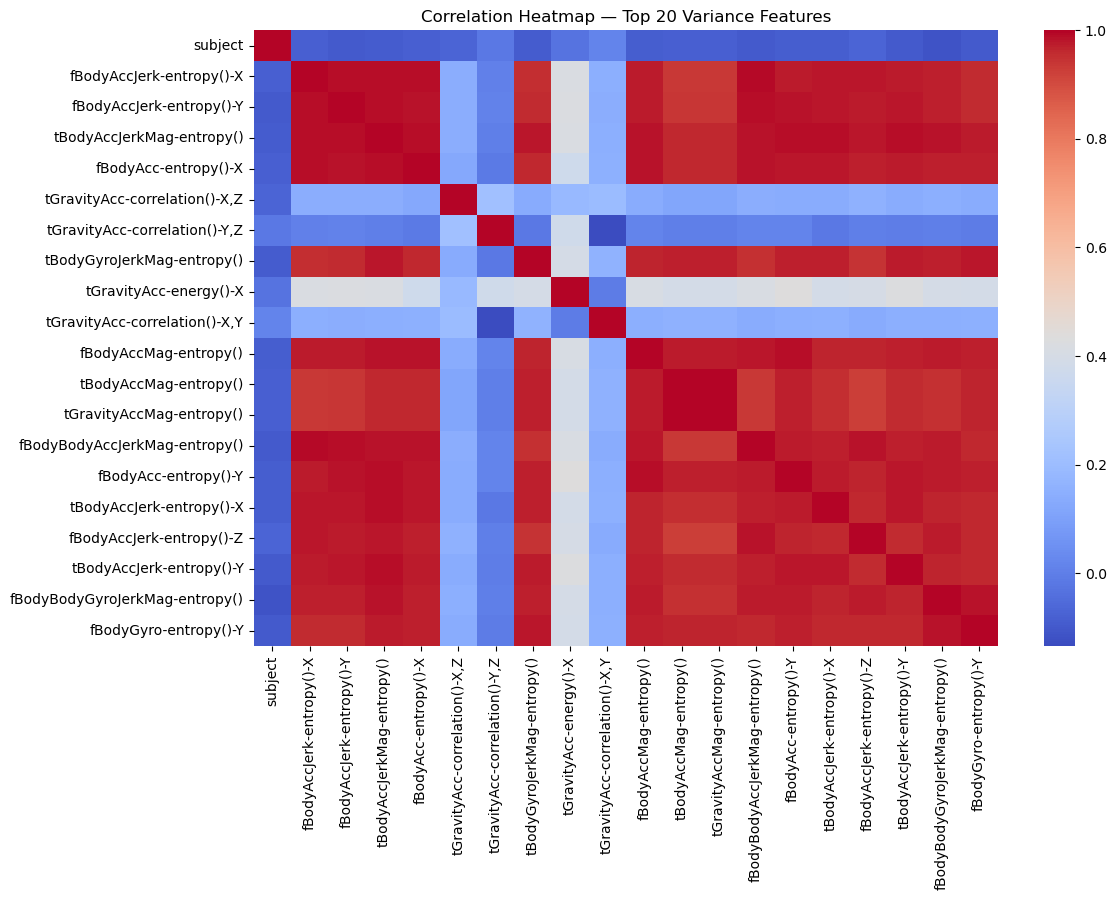

In [36]:
# select the 20 features with highest variance
dff=df.drop(columns=["Activity"])
top_var_features = dff.var(numeric_only=True).sort_values(ascending=False).head(20).index
corr_matrix = df[top_var_features].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap — Top 20 Variance Features")
plt.show()

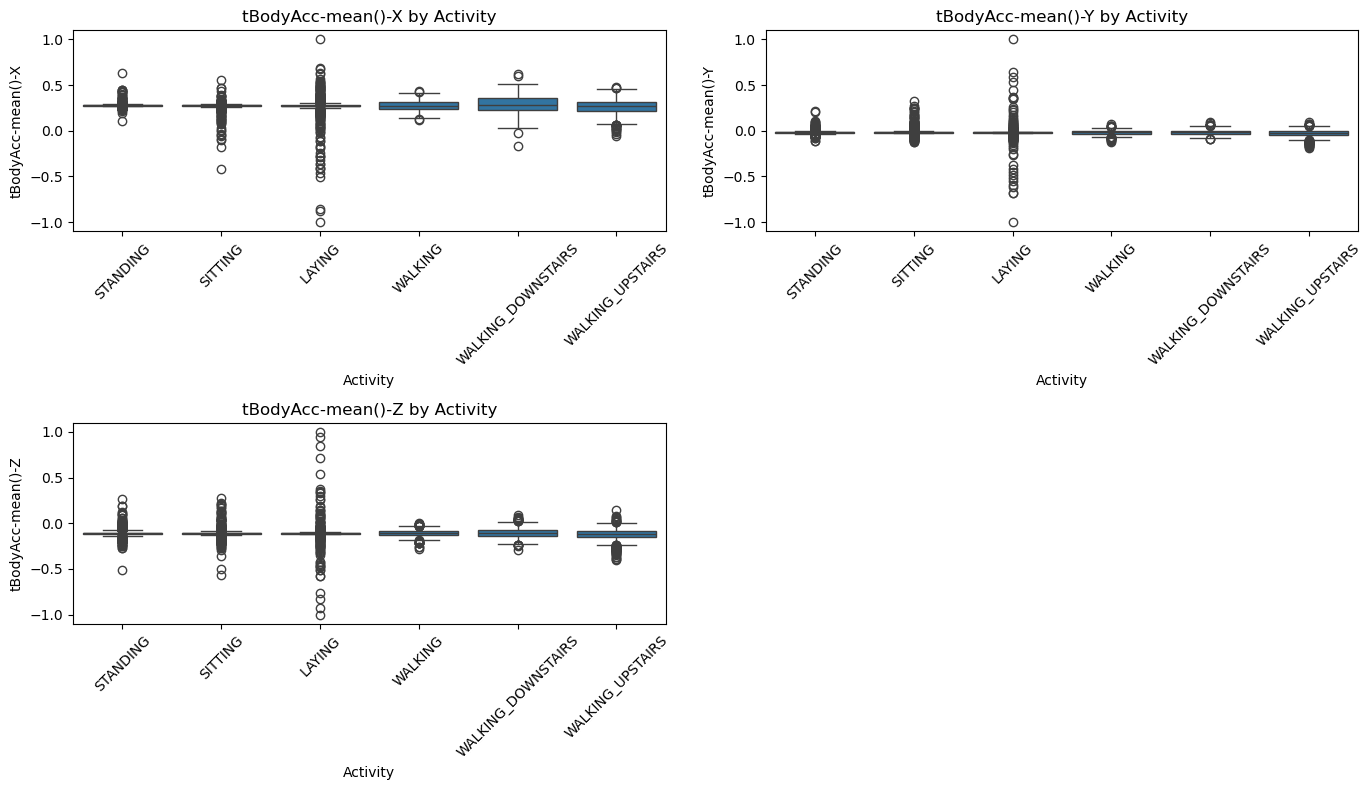

In [37]:
# Boxplot for Key Features by Activity
key_features = ['tBodyAcc-mean()-X','tBodyAcc-mean()-Y','tBodyAcc-mean()-Z']

plt.figure(figsize=(14,8))
for i,feat in enumerate(key_features):
    plt.subplot(2,2,i+1)
    sns.boxplot(data=df, x="Activity", y=feat)
    plt.xticks(rotation=45)
    plt.title(f"{feat} by Activity")
plt.tight_layout()
plt.show()


In [1]:
#Distribution of Mean and Std Features
mean_features = df.filter(regex="mean").sample(3, axis=1)  # random 3 mean features
std_features  = df.filter(regex="std").sample(3, axis=1)   # random 3 std features

mean_features.hist(figsize=(10,6))
plt.suptitle("Distribution of Sample Mean Features")
plt.show()

std_features.hist(figsize=(10,6))
plt.suptitle("Distribution of Sample Std Features")
plt.show()

NameError: name 'df' is not defined

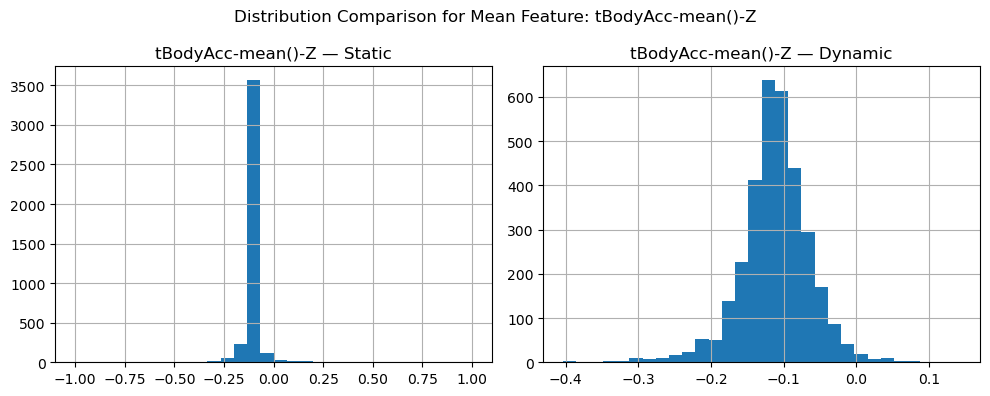

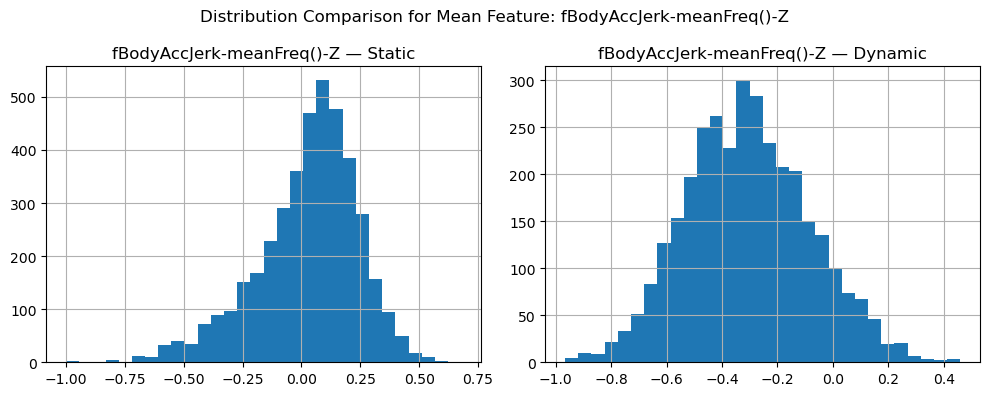

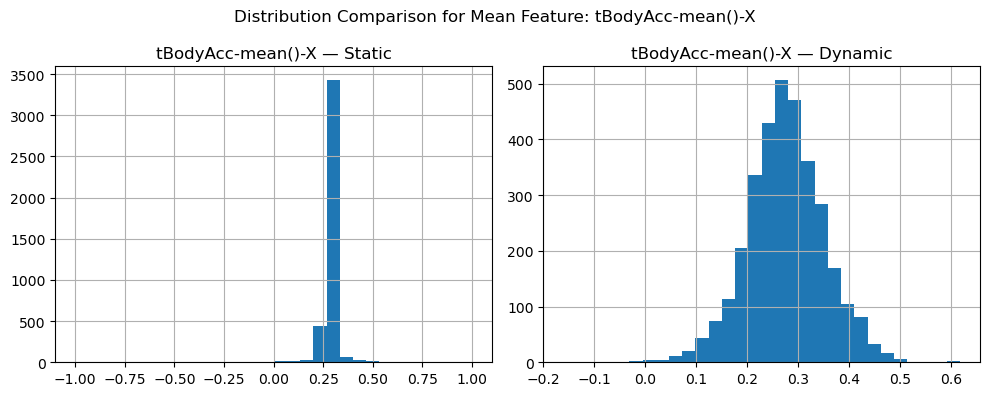

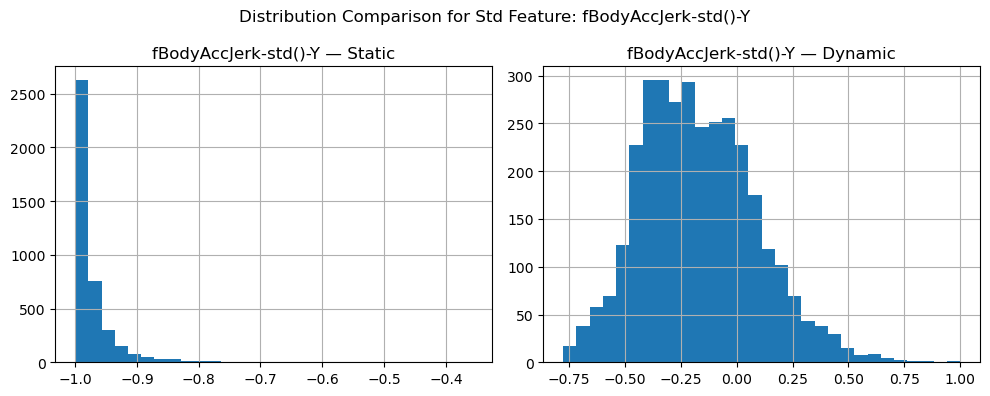

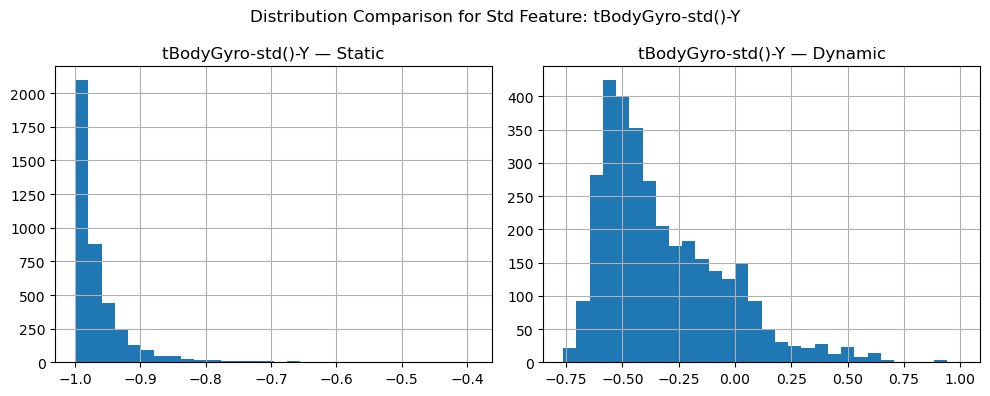

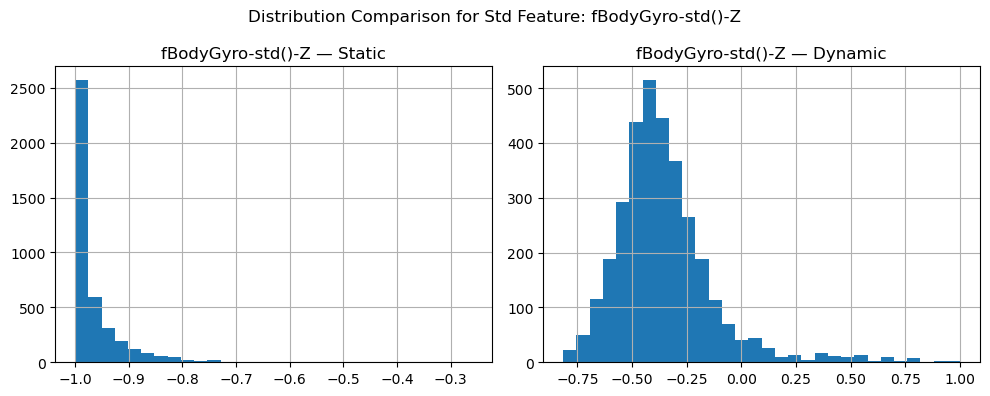

In [39]:
static_acts = ['LAYING', 'SITTING', 'STANDING']
df['ActivityType'] = df['Activity'].apply(
    lambda x: 'Static' if x in static_acts else 'Dynamic'
)
df['ActivityType'].value_counts()
# -----------------------------
#  Split the DataFrame
df_static  = df[df["ActivityType"] == "Static"]
df_dynamic = df[df["ActivityType"] == "Dynamic"]

# -----------------------------
#  Select 3 random mean & std features
# -----------------------------
mean_cols = df.filter(regex="mean").sample(3, axis=1).columns
std_cols  = df.filter(regex="std").sample(3, axis=1).columns

# -----------------------------
#  Plot Mean Feature Distribution — Static vs Dynamic
# -----------------------------
for col in mean_cols:
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    df_static[col].hist(bins=30)
    plt.title(f"{col} — Static")

    plt.subplot(1,2,2)
    df_dynamic[col].hist(bins=30)
    plt.title(f"{col} — Dynamic")

    plt.suptitle(f"Distribution Comparison for Mean Feature: {col}")
    plt.tight_layout()
    plt.show()

# -----------------------------
# Plot Std Feature Distribution — Static vs Dynamic
# -----------------------------
for col in std_cols:
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    df_static[col].hist(bins=30)
    plt.title(f"{col} — Static")

    plt.subplot(1,2,2)
    df_dynamic[col].hist(bins=30)
    plt.title(f"{col} — Dynamic")

    plt.suptitle(f"Distribution Comparison for Std Feature: {col}")
    plt.tight_layout()
    plt.show()


   Activity Feature  Average Value
0  STANDING    mean      -0.503484
1  STANDING     std      -0.963806
2  STANDING     mad      -0.965072
3  STANDING     max      -0.827471
4  STANDING     min      -0.189516


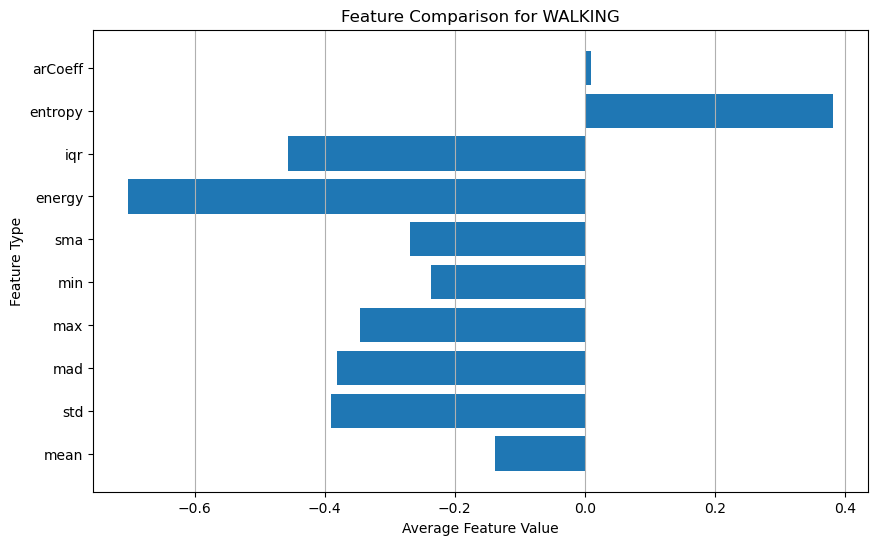

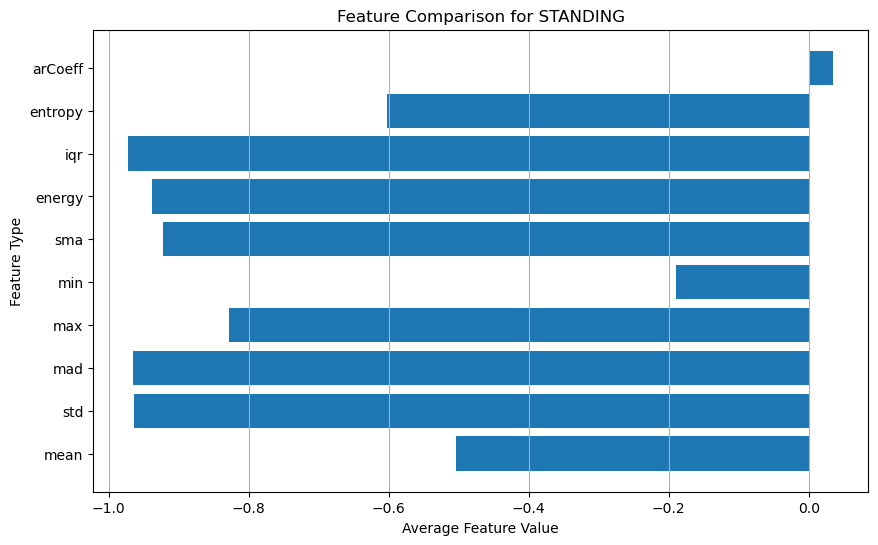

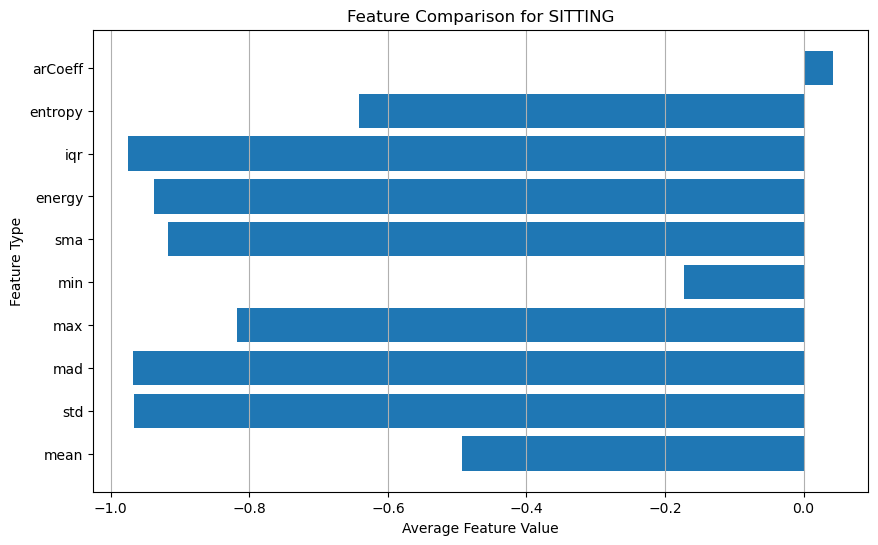

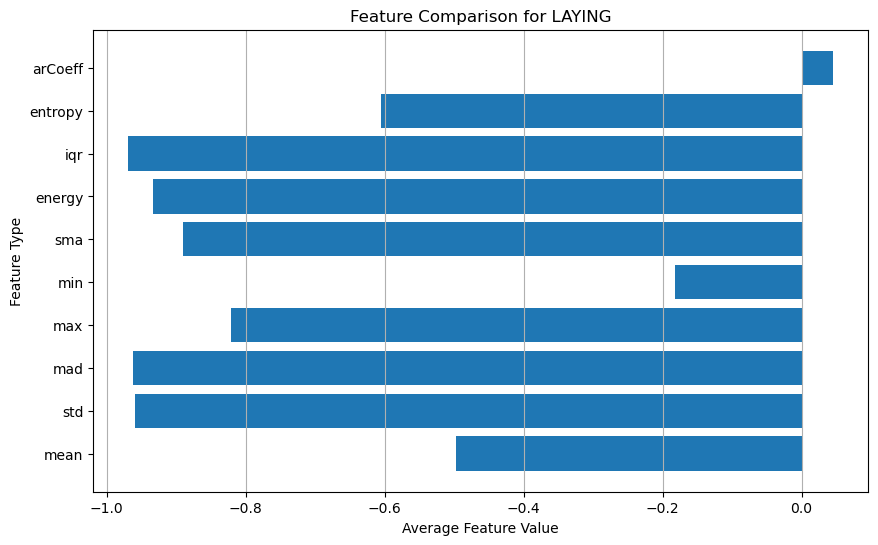

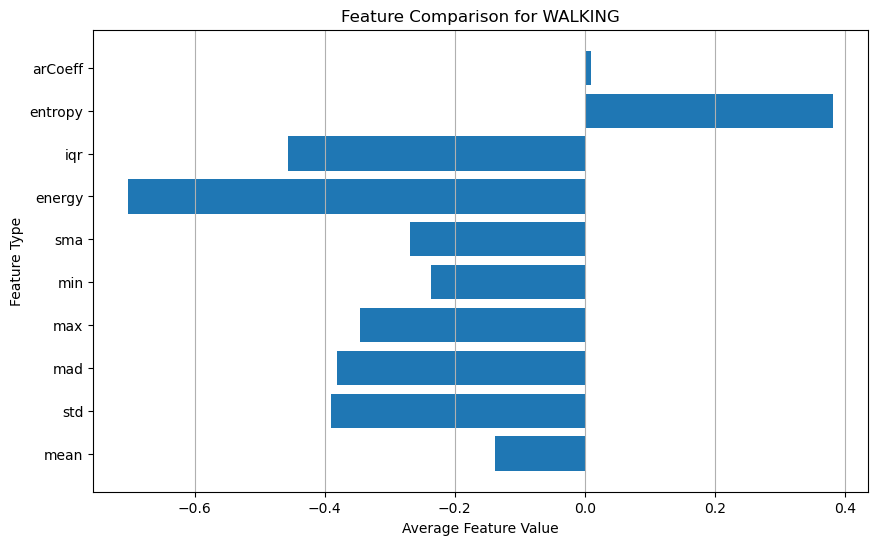

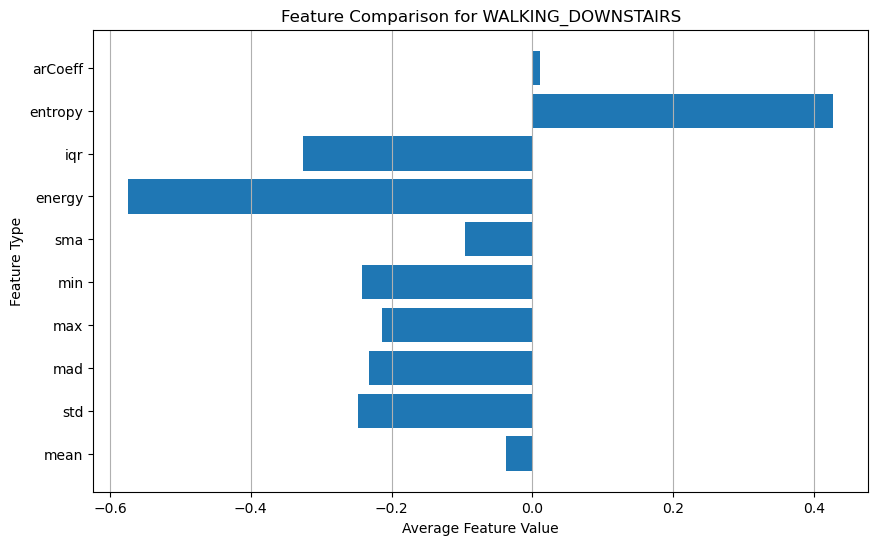

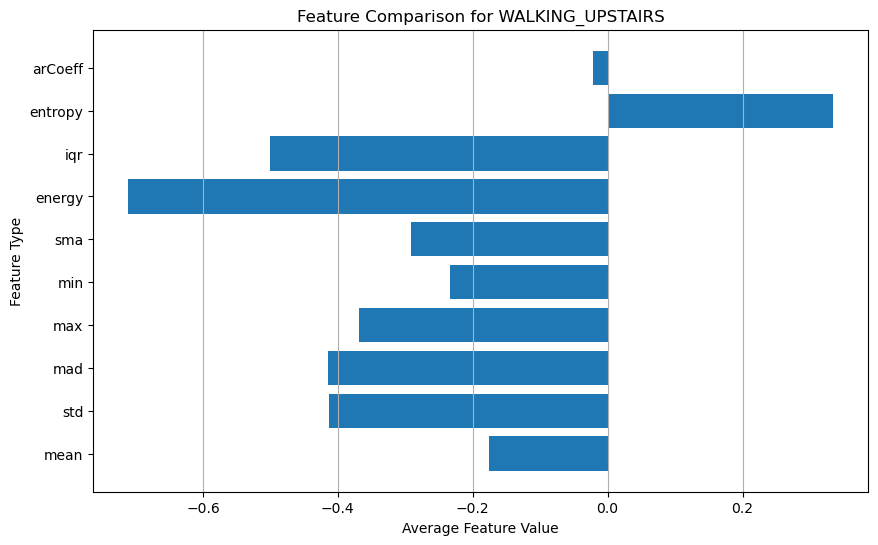

In [40]:
feature_groups = {
    "mean": "mean()",
    "std": "std()",
    "mad": "mad()",
    "max": "max()",
    "min": "min()",
    "sma": "sma()",
    "energy": "energy()",
    "iqr": "iqr()",
    "entropy": "entropy()",
    "arCoeff": "arCoeff()"
}
#Compute Feature Values Activity-wise
activity_feature_data = []

for activity in df['Activity'].unique():
    activity_df = df[df['Activity'] == activity]

    for feature, keyword in feature_groups.items():
        cols = [col for col in df.columns if keyword in col]
        avg_value = activity_df[cols].mean().mean()

        activity_feature_data.append([activity, feature, avg_value])

activity_feature_df = pd.DataFrame(
    activity_feature_data,
    columns=["Activity", "Feature", "Average Value"]
)

print(activity_feature_df.head())
#Horizontal Bar Graph (barh) — Per Activity
activity_name = "WALKING"

subset = activity_feature_df[
    activity_feature_df["Activity"] == activity_name
]

plt.figure(figsize=(10,6))
plt.barh(subset["Feature"], subset["Average Value"])
plt.xlabel("Average Feature Value")
plt.ylabel("Feature Type")
plt.title(f"Feature Comparison for {activity_name}")
plt.grid(axis='x')
plt.show()
for activity in df['Activity'].unique():
    subset = activity_feature_df[
        activity_feature_df["Activity"] == activity
    ]

    plt.figure(figsize=(10,6))
    plt.barh(subset["Feature"], subset["Average Value"])
    plt.xlabel("Average Feature Value")
    plt.ylabel("Feature Type")
    plt.title(f"Feature Comparison for {activity}")
    plt.grid(axis='x')
    plt.show()


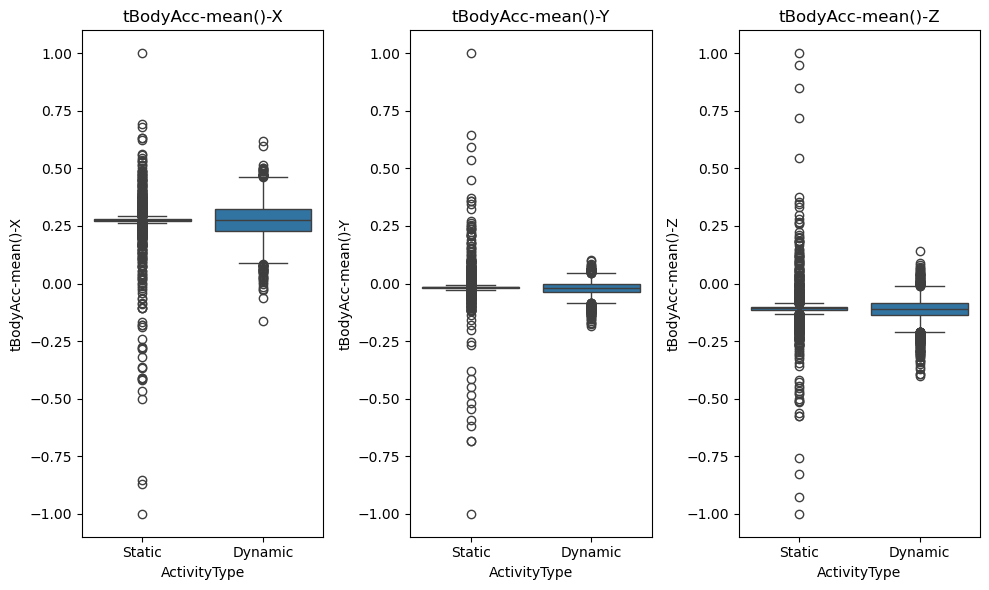

In [41]:
key_features = ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z']

plt.figure(figsize=(10,6))
for i, feat in enumerate(key_features):
    plt.subplot(1,3,i+1)
    sns.boxplot(x=df['ActivityType'], y=df[feat])
    plt.title(feat)
plt.tight_layout()
plt.show()